In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [2]:
df = pd.read_csv('data/transformed_cleaned_vw_golf.csv')
print(f'Rows: {len(df):,} | Columns: {df.shape[1]}')
df.head()


Rows: 6,920 | Columns: 28


,index,brand,model,registration_date,year,price_in_euro,power_kw,power_ps,fuel_type,fuel_consumption_l_100km,...,mileage_per_year,color_black,color_blue,color_grey,color_other,color_red,color_silver,color_white,transmission_type_Automatic,transmission_type_Manual
0,213644,volkswagen,Volkswagen Golf,1995-08-01,1995,4970,66,90,Petrol,8.0,...,670.678574,False,True,False,False,False,False,False,False,True
1,213645,volkswagen,Volkswagen Golf,1995-02-01,1995,2590,66,90,Petrol,6.8,...,613.525300,False,True,False,False,False,False,False,True,False
2,213647,volkswagen,Volkswagen Golf,1995-11-01,1995,8900,128,174,Petrol,10.5,...,683.030774,False,True,False,False,False,False,False,True,False
3,213650,volkswagen,Volkswagen Golf,1995-11-01,1995,6399,44,60,Petrol,6.8,...,309.617701,False,True,False,False,False,False,False,False,True
4,213662,volkswagen,Volkswagen Golf,1995-06-01,1995,6600,66,90,Diesel,5.0,...,669.745364,False,False,False,False,True,False,False,False,True


In [3]:
feature_cols = [
    'T_model_age', 'T_car_age', 'T_power_kw', 'T_mileage', 'mileage_per_year',
    'fuel_consumption_l_100km',
    'transmission_type_Automatic', 'transmission_type_Manual',
    'color_black', 'color_blue', 'color_grey', 'color_other', 'color_red',
    'color_silver', 'color_white'
]

X = df[feature_cols].astype(float).reset_index(drop=True)
y = df['price_in_euro'].astype(float).reset_index(drop=True)
y_log = np.log1p(y)

print('Feature shape:', X.shape)


Feature shape: (6920, 15)


In [4]:
def evaluate_fold(y_true_eur, y_pred_eur):
    rmse = float(np.sqrt(mean_squared_error(y_true_eur, y_pred_eur)))
    r2 = float(r2_score(y_true_eur, y_pred_eur))
    return rmse, r2


def run_cv(X, y, y_log, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        y_train_log = y_log.iloc[train_idx]

        lr = LinearRegression()
        lr.fit(X_train, y_train)
        lr_pred = lr.predict(X_test)
        rmse, r2 = evaluate_fold(y_test, lr_pred)
        results.append({'fold': fold, 'model': 'linear_regression', 'rmse': rmse, 'r2': r2})

        xgb = XGBRegressor(
            n_estimators=700,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
        )
        xgb.fit(X_train, y_train_log, verbose=False)
        xgb_pred = np.expm1(xgb.predict(X_test))
        rmse, r2 = evaluate_fold(y_test, xgb_pred)
        results.append({'fold': fold, 'model': 'xgboost', 'rmse': rmse, 'r2': r2})

        lgbm = LGBMRegressor(
            objective='regression',
            n_estimators=700,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            verbose=-1,
        )
        lgbm.fit(X_train, y_train_log)
        lgbm_pred = np.expm1(lgbm.predict(X_test))
        rmse, r2 = evaluate_fold(y_test, lgbm_pred)
        results.append({'fold': fold, 'model': 'lightgbm', 'rmse': rmse, 'r2': r2})

    return pd.DataFrame(results)


In [5]:
cv_results = run_cv(X, y, y_log, n_splits=5, random_state=42)
cv_results


,fold,model,rmse,r2
0,1,linear_regression,3119.222814,0.873340
1,1,xgboost,2696.558312,0.905340
2,1,lightgbm,2700.498133,0.905063
3,2,linear_regression,3465.239845,0.866943
4,2,xgboost,3079.723221,0.894902
5,2,lightgbm,3049.091349,0.896982
6,3,linear_regression,3957.120884,0.824912
7,3,xgboost,3527.664472,0.860853
8,3,lightgbm,3518.010250,0.861614
9,4,linear_regression,3546.537969,0.856571


In [6]:
summary = cv_results.groupby('model', as_index=False).agg(
    rmse_mean=('rmse', 'mean'),
    rmse_std=('rmse', 'std'),
    r2_mean=('r2', 'mean'),
    r2_std=('r2', 'std')
).sort_values('rmse_mean')

summary


,model,rmse_mean,rmse_std,r2_mean,r2_std
0,lightgbm,3094.188795,299.426901,0.887633,0.017898
2,xgboost,3114.496248,298.252172,0.886229,0.017330
1,linear_regression,3538.238494,300.265520,0.853271,0.019237


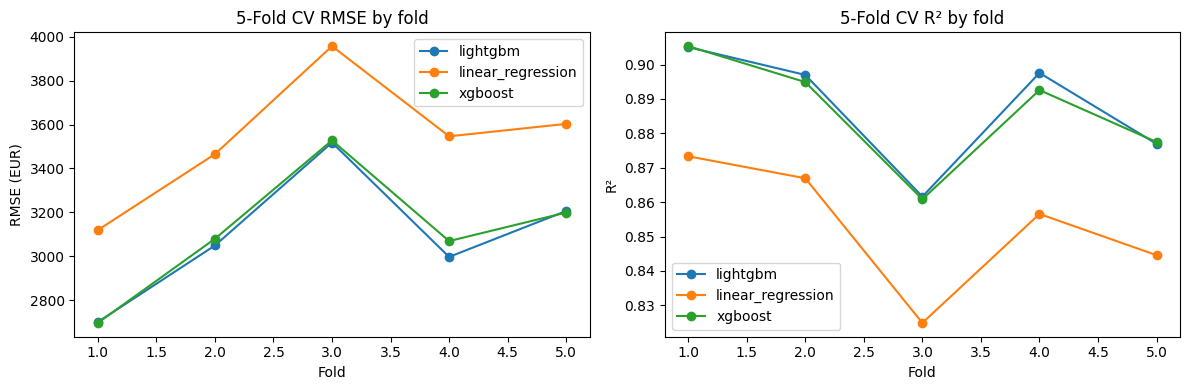

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for model, grp in cv_results.groupby('model'):
    axes[0].plot(grp['fold'], grp['rmse'], marker='o', label=model)
axes[0].set_title('5-Fold CV RMSE by fold')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('RMSE (EUR)')
axes[0].legend()

for model, grp in cv_results.groupby('model'):
    axes[1].plot(grp['fold'], grp['r2'], marker='o', label=model)
axes[1].set_title('5-Fold CV R² by fold')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('R²')
axes[1].legend()

plt.tight_layout()
plt.show()


In [8]:
cv_results.to_csv('data/cv_results_vw_golf.csv', index=False)
summary.to_csv('data/cv_results_vw_golf_summary.csv', index=False)
print('Saved: data/cv_results_vw_golf.csv')
print('Saved: data/cv_results_vw_golf_summary.csv')


Saved: data/cv_results_vw_golf.csv
Saved: data/cv_results_vw_golf_summary.csv
